<a href="https://colab.research.google.com/github/jaeho0726/Sentiment-Analysis/blob/main/Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Setup and Dependencies**

In [1]:
!set -x \
&& pip install konlpy \
&& curl -s https://raw.githubusercontent.com/konlpy/master/scripts/mecab.sh | bash

+ pip install konlpy
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 20.8 MB/s eta 0:00:00
+ curl -s https://raw.githubusercontent.com/konlpy/master/scripts/mecab.sh
+ bash
bash: line 1: 404:: command not found


## **2. Import Libraries and Configuration**


In [2]:
import re

import urllib.request
import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch.utils.data import Dataset
import torch.nn.functional as F

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_style("white")

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

from collections import Counter

## **3. Naver Movie Review Data: Loading and Initial Cleaning**

In [3]:
# Accessing Naver movie review data
train_file = urllib.request.urlopen("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt")
test_file = urllib.request.urlopen("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt")

train_data = pd.read_table(train_file)
test_data = pd.read_table(test_file)

train_data[:10]

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1
5,5403919,막 걸음마 뗀 3세부터 초등학교 1학년생인 8살용영화.ㅋㅋㅋ...별반개도 아까움.,0
6,7797314,원작의 긴장감을 제대로 살려내지못했다.,0
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지..정말 발로해도 그것보단...,0
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1
9,5912145,왜케 평점이 낮은건데? 꽤 볼만한데.. 헐리우드식 화려함에만 너무 길들여져 있나?,1


In [4]:
# Finding numbers of data in train data
print(train_data['document'].nunique())
print(train_data['label'].nunique())

train_data.drop_duplicates(subset=['document'], inplace = True)

146182
2


In [5]:
# Finding missing values in train data
print(train_data.isnull().sum())

train_data = train_data.dropna(how='any')

id          0
document    1
label       0
dtype: int64


In [6]:
# Getting rid of characters except Korean characters and blank spaces
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]", "", regex=True)

train_data[:10]

,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,1
5,5403919,막 걸음마 뗀 세부터 초등학교 학년생인 살용영화ㅋㅋㅋ별반개도 아까움,0
6,7797314,원작의 긴장감을 제대로 살려내지못했다,0
7,9443947,별 반개도 아깝다 욕나온다 이응경 길용우 연기생활이몇년인지정말 발로해도 그것보단 낫...,0
8,7156791,액션이 없는데도 재미 있는 몇안되는 영화,1
9,5912145,왜케 평점이 낮은건데 꽤 볼만한데 헐리우드식 화려함에만 너무 길들여져 있나,1


In [7]:
train_data['document'] = train_data['document'].replace('', np.nan)
print(len(train_data))
print(train_data.isnull().sum())

146182
id            0
document    391
label         0
dtype: int64


In [8]:
train_data = train_data.dropna(how='any')
print(len(train_data))

145791


In [9]:
# Loading the KLUE-BERT Tokenizer and Model
tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")

class NSMCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        # Replace encode_plus with the direct tokenizer call
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Prepare the data objects
train_dataset = NSMCDataset(train_data['document'].tolist(), train_data['label'].tolist(), tokenizer)
test_dataset = NSMCDataset(test_data['document'].tolist(), test_data['label'].tolist(), tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

## **4. KLUE-BERT Model Preparation and Training**

In [10]:
# Loading pre-trained KLUE-BERT model for classification
model = AutoModelForSequenceClassification.from_pretrained("klue/bert-base", num_labels=2)

# Setting up training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-5,
    logging_steps=100,
    fp16=True if torch.cuda.is_available() else False
)

# Initialize the Trainer and start training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

trainer.train()

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on you

Step,Training Loss


KeyboardInterrupt: 

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [16]:
def bert_predict(text):
  model.eval()
  inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)

  with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)
    pros_prob = probs[0][1].item()
    centered_score = (pros_prob - 0.5) * 2

    return centered_score * 100

## **5. Daily Journal Data: Loading and Sentiment Analysis**

In [17]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default

creds, _ = default()

gc = gspread.Client(auth=creds)

spreadsheet = gc.open_by_url('https://docs.google.com/spreadsheets/d/1DrDCLitpXZyJajcWYcMNcJCZU4Xa0aE_gj4sfXzl6x4/edit?gid=0#gid=0')

worksheet = spreadsheet.worksheet('data')

In [18]:
raw = worksheet.get_all_records()

headers = raw[0]
rows = raw[1:]

df = pd.DataFrame(rows, columns=headers)

# Shortening Column Names
df = df.rename(columns={
    "Work Intensity (0 - Easy / 10 - Intense)": "Work Intensity",
    "Overall Mood (0 - Poor / 10 - Great)": "Overall Mood",
    "Name": "Date"
})

# Fixing Data Types
df["Hours of Work"] = pd.to_numeric(df["Hours of Work"], errors="coerce").fillna(0)
df["Work Intensity"] = pd.to_numeric(df["Work Intensity"], errors="coerce").fillna(0)
df["Overall Mood"] = pd.to_numeric(df["Overall Mood"], errors="coerce").fillna(0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df['Day_of_Week'] = df['Date'].dt.day_name()


df

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Reflection,Day_of_Week
0,2026-01-25,On Duty,2.5,2,6,"비록 주말이지만, 차수의 진짜 마지막이라고 할 수 있는 병력 인계가 있는 날이었다....",Sunday
2,2026-01-26,On Duty,8.0,1,6,드디어 비차수 첫출근이었다. 사실 전에는 비차수가 반갑고 정말 고프다고 느꼈지만 바...,Monday
1,2026-01-27,On Duty,8.0,1,5,오늘은 비차수 두번째 날이었다. 어저께는 보드게임과 오목으로 심심함을 이겨낼 수 있...,Tuesday
3,2026-01-28,On Duty,7.0,1,7,오늘은 평소보다 일찍 출근하는 워라벨이었다. 어저께 오랜만에 못참고 라면을 먹어서 ...,Wednesday
4,2026-01-29,On Duty,8.0,1,9,오늘도 어김없이 그동안의 비차수와 다름 없는 하루로 시작했다. 출근해서 밥에 닭가슴...,Thursday
...,...,...,...,...,...,...,...
65,2026-04-05,Military Leave,0.0,0,9,드디어 휴가다! 2월 말 이후로 처음 나가는 휴가다. 그 사이에 외출도 많이 나갔지...,Sunday
66,2026-04-06,Military Leave,0.0,0,8,오랜만에 친구들을 만났다. 저녁에 오랜만에 은규랑 연준이랑 밥을 먹기로 했다. 그 ...,Monday
67,2026-04-07,Military Leave,0.0,0,6,어저께 생각 이상으로 과음을 해서 그런지 속이 하루 종일 불편했던 것 같다. 안그래...,Tuesday
68,2026-04-08,Military Leave,0.0,0,4,오늘은 엄마가 입원하시는 날이다. 수술이라는 단어 자체가 아픈 것을 넘어서 나에게는...,Wednesday


In [19]:
df['Sentiment Score'] = df['Reflection'].apply(bert_predict)

df

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Reflection,Day_of_Week,Sentiment Score
0,2026-01-25,On Duty,2.5,2,6,"비록 주말이지만, 차수의 진짜 마지막이라고 할 수 있는 병력 인계가 있는 날이었다....",Sunday,-93.991326
2,2026-01-26,On Duty,8.0,1,6,드디어 비차수 첫출근이었다. 사실 전에는 비차수가 반갑고 정말 고프다고 느꼈지만 바...,Monday,-75.411239
1,2026-01-27,On Duty,8.0,1,5,오늘은 비차수 두번째 날이었다. 어저께는 보드게임과 오목으로 심심함을 이겨낼 수 있...,Tuesday,93.555534
3,2026-01-28,On Duty,7.0,1,7,오늘은 평소보다 일찍 출근하는 워라벨이었다. 어저께 오랜만에 못참고 라면을 먹어서 ...,Wednesday,-16.361612
4,2026-01-29,On Duty,8.0,1,9,오늘도 어김없이 그동안의 비차수와 다름 없는 하루로 시작했다. 출근해서 밥에 닭가슴...,Thursday,-36.081529
...,...,...,...,...,...,...,...,...
65,2026-04-05,Military Leave,0.0,0,9,드디어 휴가다! 2월 말 이후로 처음 나가는 휴가다. 그 사이에 외출도 많이 나갔지...,Sunday,97.614682
66,2026-04-06,Military Leave,0.0,0,8,오랜만에 친구들을 만났다. 저녁에 오랜만에 은규랑 연준이랑 밥을 먹기로 했다. 그 ...,Monday,-93.389050
67,2026-04-07,Military Leave,0.0,0,6,어저께 생각 이상으로 과음을 해서 그런지 속이 하루 종일 불편했던 것 같다. 안그래...,Tuesday,58.605158
68,2026-04-08,Military Leave,0.0,0,4,오늘은 엄마가 입원하시는 날이다. 수술이라는 단어 자체가 아픈 것을 넘어서 나에게는...,Wednesday,49.239361


In [20]:
def categorize_sentiment(score):
  if score > 0:
    return '긍정'
  elif score < 0:
    return '부정'
  else:
    return '중립'

df['Sentiment'] = df['Sentiment Score'].apply(categorize_sentiment)

df

,Date,Today's Status,Hours of Work,Work Intensity,Overall Mood,Reflection,Day_of_Week,Sentiment Score,Sentiment
0,2026-01-25,On Duty,2.5,2,6,"비록 주말이지만, 차수의 진짜 마지막이라고 할 수 있는 병력 인계가 있는 날이었다....",Sunday,-93.991326,부정
2,2026-01-26,On Duty,8.0,1,6,드디어 비차수 첫출근이었다. 사실 전에는 비차수가 반갑고 정말 고프다고 느꼈지만 바...,Monday,-75.411239,부정
1,2026-01-27,On Duty,8.0,1,5,오늘은 비차수 두번째 날이었다. 어저께는 보드게임과 오목으로 심심함을 이겨낼 수 있...,Tuesday,93.555534,긍정
3,2026-01-28,On Duty,7.0,1,7,오늘은 평소보다 일찍 출근하는 워라벨이었다. 어저께 오랜만에 못참고 라면을 먹어서 ...,Wednesday,-16.361612,부정
4,2026-01-29,On Duty,8.0,1,9,오늘도 어김없이 그동안의 비차수와 다름 없는 하루로 시작했다. 출근해서 밥에 닭가슴...,Thursday,-36.081529,부정
...,...,...,...,...,...,...,...,...,...
65,2026-04-05,Military Leave,0.0,0,9,드디어 휴가다! 2월 말 이후로 처음 나가는 휴가다. 그 사이에 외출도 많이 나갔지...,Sunday,97.614682,긍정
66,2026-04-06,Military Leave,0.0,0,8,오랜만에 친구들을 만났다. 저녁에 오랜만에 은규랑 연준이랑 밥을 먹기로 했다. 그 ...,Monday,-93.389050,부정
67,2026-04-07,Military Leave,0.0,0,6,어저께 생각 이상으로 과음을 해서 그런지 속이 하루 종일 불편했던 것 같다. 안그래...,Tuesday,58.605158,긍정
68,2026-04-08,Military Leave,0.0,0,4,오늘은 엄마가 입원하시는 날이다. 수술이라는 단어 자체가 아픈 것을 넘어서 나에게는...,Wednesday,49.239361,긍정


## **6. Analysis and Visualization**

In [21]:
on_duty = df[df["Today's Status"] == "On Duty"].copy()

pos_df = df[df['Sentiment'] == '긍정'].copy()
neg_df = df[df['Sentiment'] == '부정'].copy()

In [22]:
def extract_korean_words(text_series):
    words = []
    for text in text_series:
        if isinstance(text, str):
            found = re.findall(r'[가-힣]{2,}', text)
            words.extend(found)
    return Counter(words)

# Common filler words to exclude
filler = {'오늘', '정말', '것이', '것도', '것을', '것은', '것같', '같다', '같은',
          '하지만', '그래도', '이번', '생각', '때문', '느낌', '그리고', '하면서',
          '있는', '있었', '없는', '없었', '했던', '했다', '했는데', '했고',
          '이라', '에서', '에게', '으로', '에도', '했을', '이었', '이다',
          '한다', '한것', '해서', '하고', '하는', '이번에', '오늘도', '그래서'}

def top_words(counter, n=30):
    return [(w, c) for w, c in counter.most_common(200)
            if w not in filler][:n]

print("Extracting words...")
pos_words = top_words(extract_korean_words(pos_df['Reflection']))
neg_words = top_words(extract_korean_words(neg_df['Reflection']))

Extracting words...


In [23]:
# High mood but negative sentiment
false_neg = df[(df['Overall Mood'] >= 7) & (df['Sentiment Score'] < 0)].copy()
# Low mood but positive sentiment
false_pos = df[(df['Overall Mood'] <= 4) & (df['Sentiment Score'] > 0)].copy()

df['Discrepancy Type'] = 'Aligned'
df.loc[false_neg.index, 'Discrepancy Type'] = 'High Mood / Negative Text'
df.loc[false_pos.index, 'Discrepancy Type'] = 'Low Mood / Positive Text'

/tmp/ipykernel_600/4257581595.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Today's Status", y='Sentiment Score',
/tmp/ipykernel_600/4257581595.py:123: UserWarning: Glyph 44557 (\N{HANGUL SYLLABLE GEUNG}) missing from font(s) DejaVu Sans.
  plt.savefig('journal_kluebert_analysis.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_600/4257581595.py:123: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.savefig('journal_kluebert_analysis.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_600/4257581595.py:123: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.savefig('journal_kluebert_analysis.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_600/4257581595.py:123: UserWarning: Glyph 47004 (\N{HANGUL SYLLABLE RAEN}) missing from font(s) De

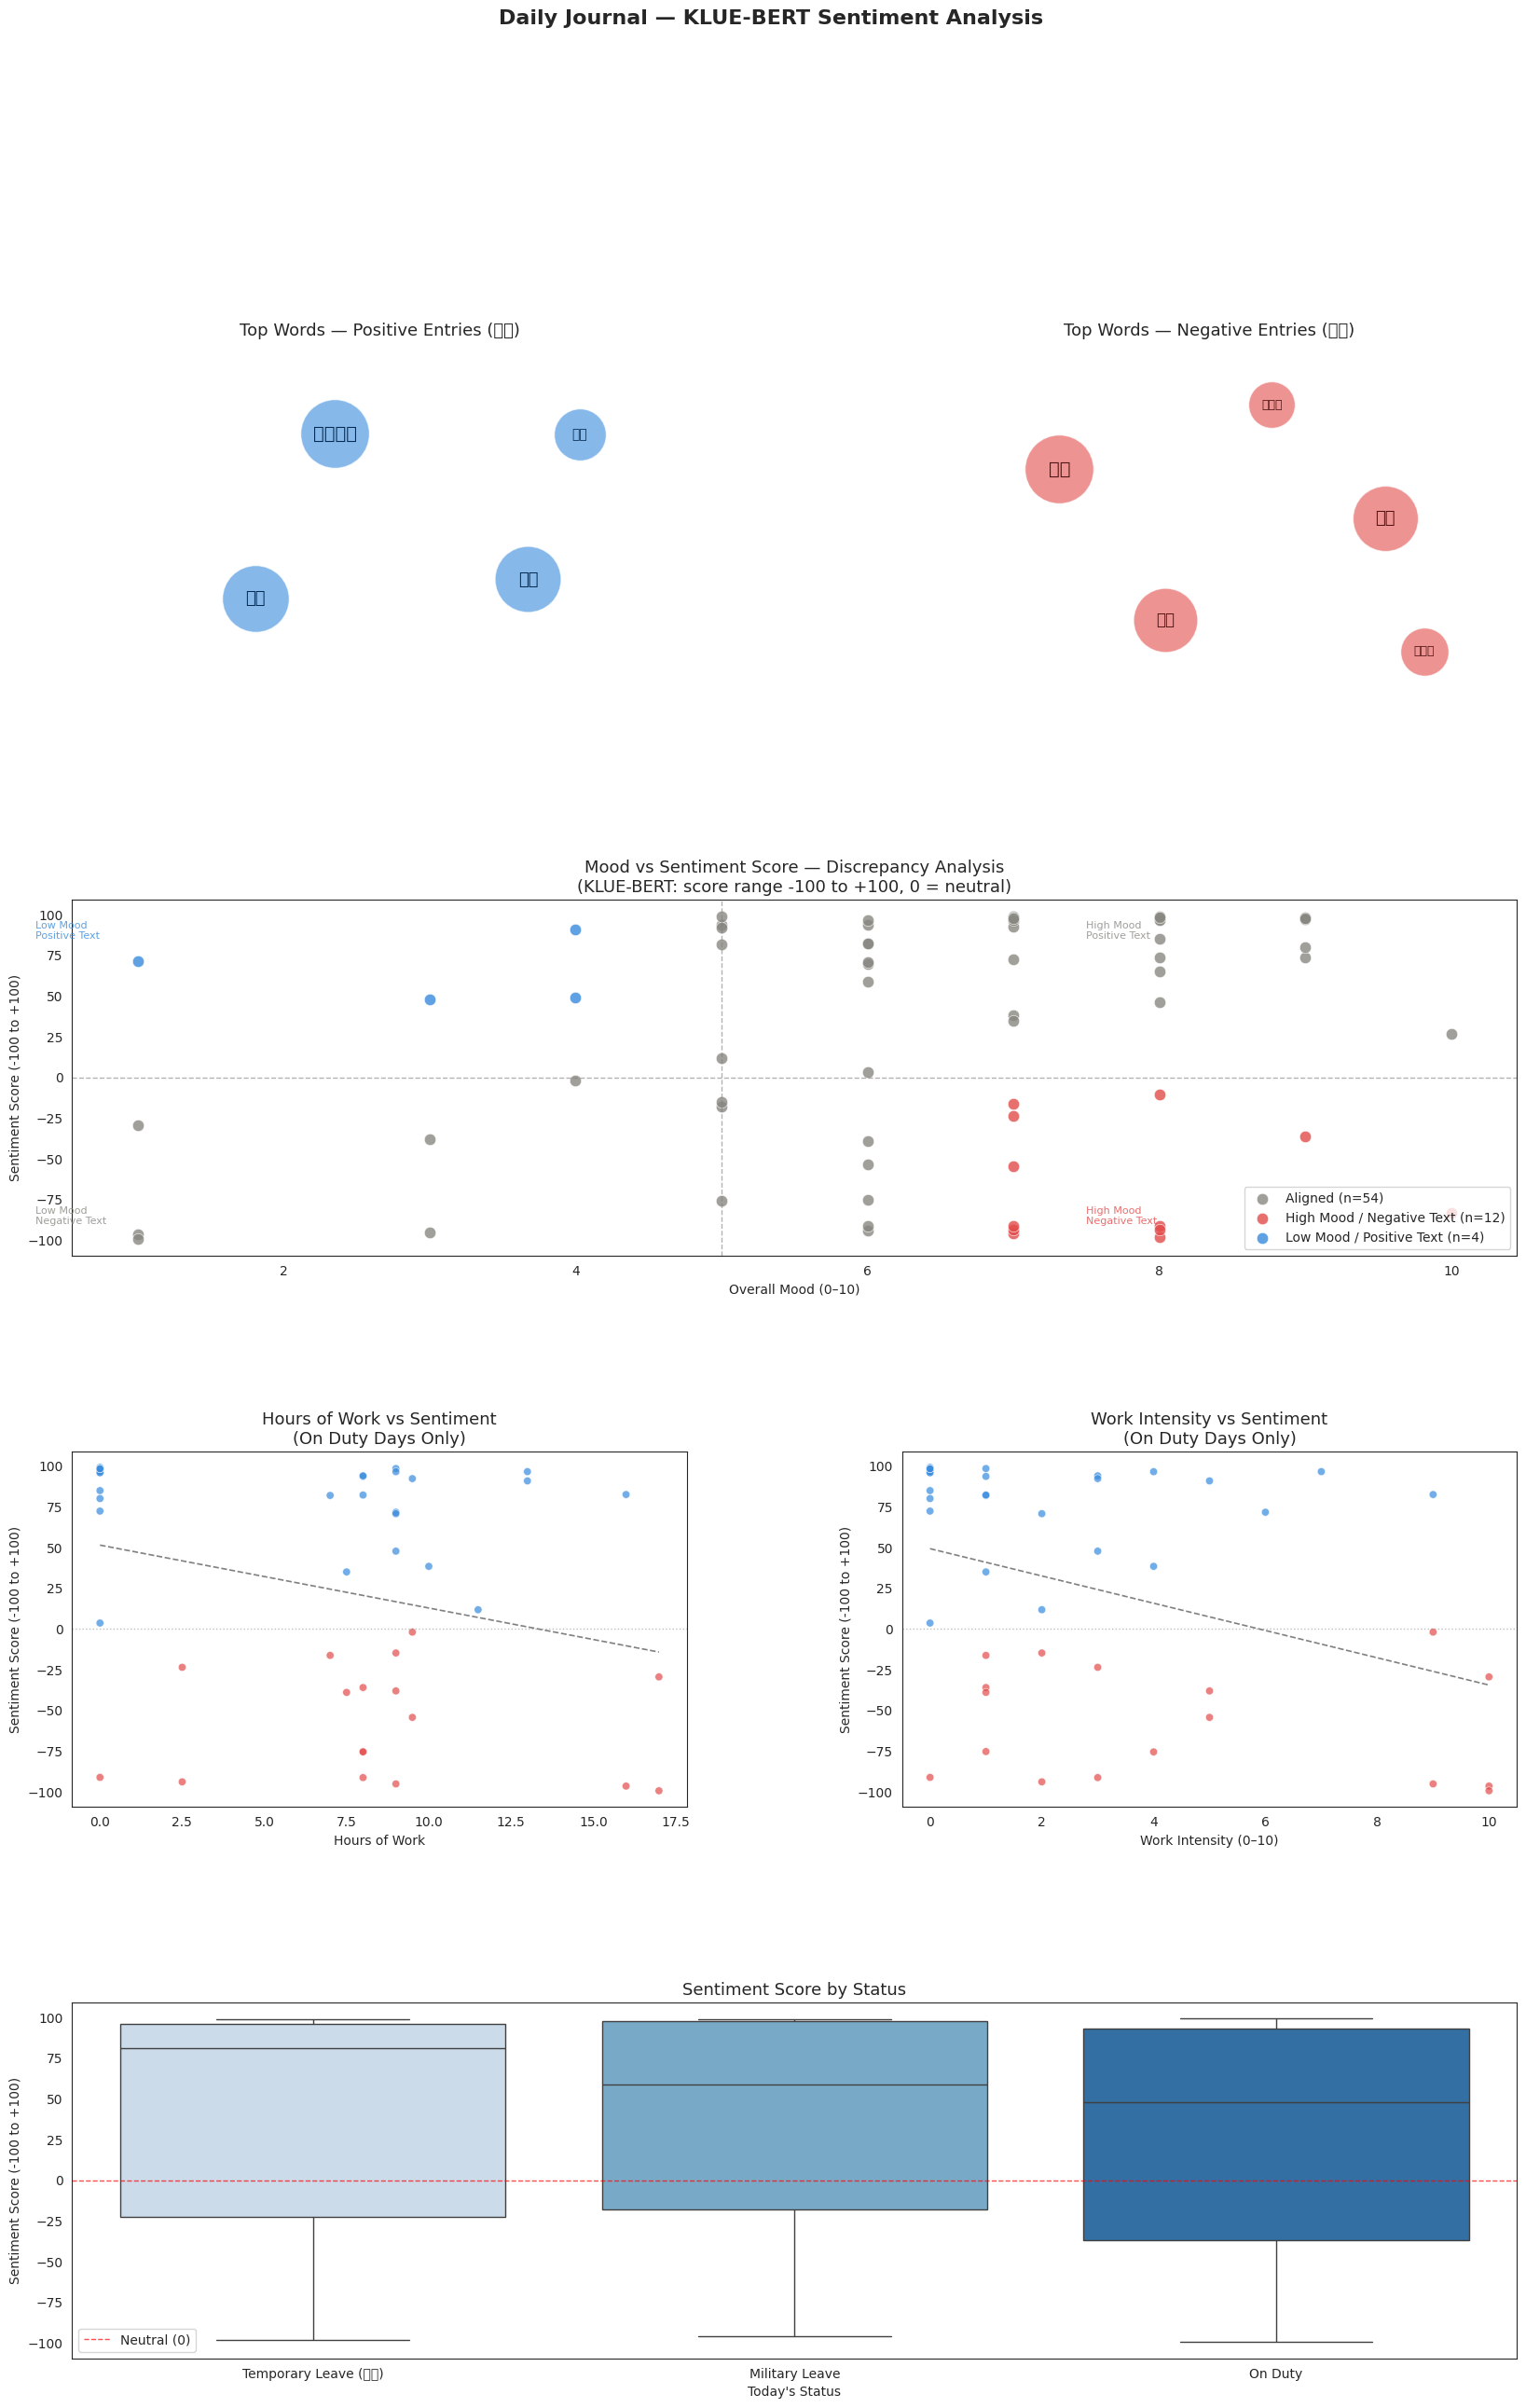

In [24]:
fig = plt.figure(figsize=(20, 28))
gs  = gridspec.GridSpec(nrows=4, ncols=2, figure=fig, hspace=0.55, wspace=0.35)

# Positive Word Bubble Chart
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.set_title('Top Words — Positive Entries (긍정)', fontsize=13, pad=10)

if pos_words:
    max_freq = pos_words[0][1]
    np.random.seed(42)
    placed = []
    for word, freq in pos_words:
        size   = 300 + (freq / max_freq) * 2500
        radius = np.sqrt(size) / 250
        for _ in range(500):
            x, y = np.random.uniform(radius, 1 - radius), np.random.uniform(radius, 1 - radius)
            if all(np.sqrt((x-px)**2 + (y-py)**2) > radius + pr + 0.02
                   for px, py, pr in placed):
                placed.append((x, y, radius))
                ax1.scatter(x, y, s=size, color='#378ADD', alpha=0.6,
                            edgecolors='white', linewidths=0.8)
                ax1.text(x, y, word, ha='center', va='center',
                         fontsize=max(7, int(6 + (freq / max_freq) * 8)),
                         color='#042C53', fontweight='500')
                break

# Negative Word Bubble Chart
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('Top Words — Negative Entries (부정)', fontsize=13, pad=10)

if neg_words:
    max_freq = neg_words[0][1]
    np.random.seed(7)
    placed = []
    for word, freq in neg_words:
        size   = 300 + (freq / max_freq) * 2500
        radius = np.sqrt(size) / 250
        for _ in range(500):
            x, y = np.random.uniform(radius, 1 - radius), np.random.uniform(radius, 1 - radius)
            if all(np.sqrt((x-px)**2 + (y-py)**2) > radius + pr + 0.02
                   for px, py, pr in placed):
                placed.append((x, y, radius))
                ax2.scatter(x, y, s=size, color='#E24B4A', alpha=0.6,
                            edgecolors='white', linewidths=0.8)
                ax2.text(x, y, word, ha='center', va='center',
                         fontsize=max(7, int(6 + (freq / max_freq) * 8)),
                         color='#501313', fontweight='500')
                break

# Mood vs Sentiment Discrepancy Scatter
ax3 = fig.add_subplot(gs[1, :])
color_map = {
    'Aligned':                 '#888780',
    'High Mood / Negative Text': '#E24B4A',
    'Low Mood / Positive Text':  '#378ADD'
}
for dtype, group in df.groupby('Discrepancy Type'):
    ax3.scatter(group['Overall Mood'], group['Sentiment Score'],
                label=f"{dtype} (n={len(group)})",
                color=color_map[dtype], alpha=0.8, s=80,
                edgecolors='white', linewidths=0.5)

ax3.axhline(0,  color='gray', linestyle='--', linewidth=1, alpha=0.6)  # neutral line
ax3.axvline(5,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax3.set_title('Mood vs Sentiment Score — Discrepancy Analysis\n(KLUE-BERT: score range -100 to +100, 0 = neutral)',
              fontsize=13)
ax3.set_xlabel('Overall Mood (0–10)')
ax3.set_ylabel('Sentiment Score (-100 to +100)')
ax3.legend(fontsize=10)

ax3.text(0.3, 85,  'Low Mood\nPositive Text',  fontsize=8, color='#378ADD', alpha=0.8)
ax3.text(7.5, 85,  'High Mood\nPositive Text', fontsize=8, color='#888780', alpha=0.8)
ax3.text(0.3, -90, 'Low Mood\nNegative Text',  fontsize=8, color='#888780', alpha=0.8)
ax3.text(7.5, -90, 'High Mood\nNegative Text', fontsize=8, color='#E24B4A', alpha=0.8)

# Hours of Work vs Sentiment (On Duty Only)
ax4 = fig.add_subplot(gs[2, 0])
colors_duty = on_duty['Sentiment'].map({'긍정': '#378ADD', '부정': '#E24B4A', '중립': '#888780'})
ax4.scatter(on_duty['Hours of Work'], on_duty['Sentiment Score'],
            c=colors_duty, alpha=0.7, edgecolors='white', linewidths=0.5)
if len(on_duty) > 1:
    m, b = np.polyfit(on_duty['Hours of Work'], on_duty['Sentiment Score'], 1)
    x_line = np.linspace(on_duty['Hours of Work'].min(), on_duty['Hours of Work'].max(), 100)
    ax4.plot(x_line, m * x_line + b, color='gray', linestyle='--', linewidth=1.2)
ax4.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax4.set_title('Hours of Work vs Sentiment\n(On Duty Days Only)', fontsize=13)
ax4.set_xlabel('Hours of Work')
ax4.set_ylabel('Sentiment Score (-100 to +100)')

# Work Intensity vs Sentiment (On Duty Only)
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(on_duty['Work Intensity'], on_duty['Sentiment Score'],
            c=colors_duty, alpha=0.7, edgecolors='white', linewidths=0.5)
if len(on_duty) > 1:
    m2, b2 = np.polyfit(on_duty['Work Intensity'], on_duty['Sentiment Score'], 1)
    x_line2 = np.linspace(on_duty['Work Intensity'].min(), on_duty['Work Intensity'].max(), 100)
    ax5.plot(x_line2, m2 * x_line2 + b2, color='gray', linestyle='--', linewidth=1.2)
ax5.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax5.set_title('Work Intensity vs Sentiment\n(On Duty Days Only)', fontsize=13)
ax5.set_xlabel('Work Intensity (0–10)')
ax5.set_ylabel('Sentiment Score (-100 to +100)')

# Sentiment Score by Status (Boxplot)
ax6 = fig.add_subplot(gs[3, :])
status_order = (df.groupby("Today's Status")['Sentiment Score']
                  .median().sort_values(ascending=False).index)
sns.boxplot(data=df, x="Today's Status", y='Sentiment Score',
            order=status_order, palette='Blues', ax=ax6)
ax6.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Neutral (0)')
ax6.set_title('Sentiment Score by Status', fontsize=13)
ax6.set_xlabel("Today's Status")
ax6.set_ylabel('Sentiment Score (-100 to +100)')
ax6.legend()

plt.suptitle('Daily Journal — KLUE-BERT Sentiment Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('journal_kluebert_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from scipy.stats import pearsonr

# Calculate Pearson correlation between Sentiment Score and Overall Mood
# Note: pearsonr returns the correlation coefficient and the p-value.
correlation_coefficient, p_value = pearsonr(df['Sentiment Score'], df['Overall Mood'])

print(f"Pearson Correlation between Sentiment Score and Overall Mood: {correlation_coefficient:.3f}")
print(f"P-value: {p_value:.3f}")

if correlation_coefficient > 0.7:
    print("There is a strong positive correlation, suggesting the model's sentiment largely aligns with your overall mood.")
elif correlation_coefficient > 0.3:
    print("There is a moderate positive correlation.")
elif correlation_coefficient < -0.7:
    print("There is a strong negative correlation, which might indicate a mismatch or inverse relationship.")
elif correlation_coefficient < -0.3:
    print("There is a moderate negative correlation.")
else:
    print("The correlation is weak, suggesting a limited linear relationship between the sentiment score and overall mood.")